# 手写实现一个Lora

## 基本原理

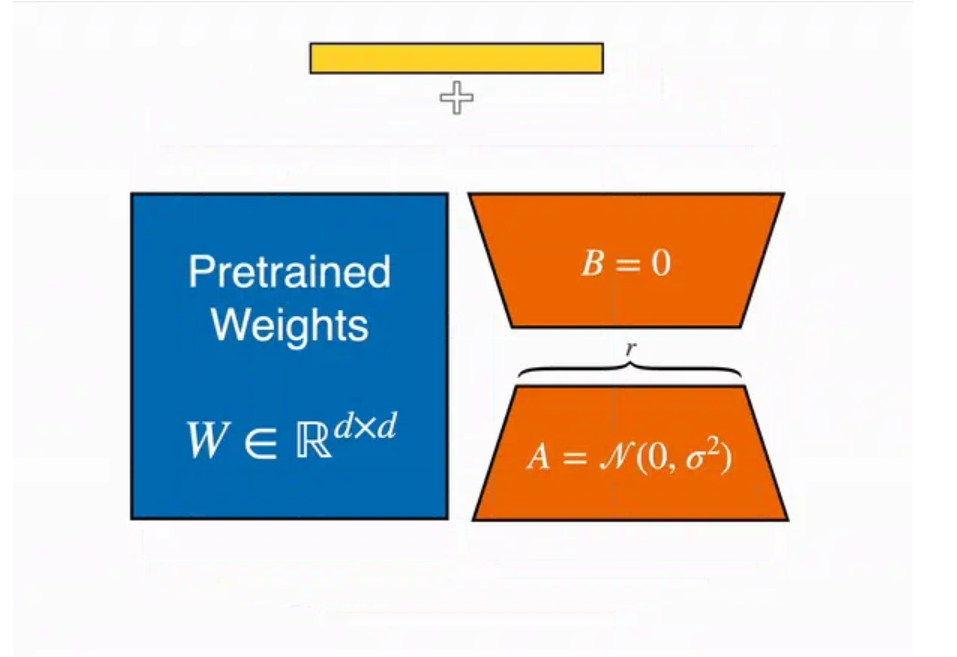

原理：低秩假设，
（`Inspired by this, we hypothe size the updates to the weights also have a low “intrinsic rank” during adaptation.`）

具体来说对于线性层：
- forward：原矩阵 W 和 近似矩阵 A，B ( $ W \approx B A$ ) 结果的和
- backward：冻结原矩阵 W 只更新近似矩阵 A，B 参数

伪代码：
```py
# 它其实就是一个形状为 (out_features, in_features) 的权重矩阵。
W = nn.Linear(in_features, out_featues, biase=False)

# 这里的 r 对应的是论文的 LowRank
lora_a = nn.Linear(in_features, r, biase=False)
lora_b = nn.Linear(r, out_featues, biase=False)

# forward:
W(x) + lora_b(lora_a)
```

## 代码实现

In [1]:
import torch
import torch.nn as nn
import torch.functional as F
import copy

In [9]:
class LoraLinear(nn.Module):
    def __init__(self, 
                 base_layer : nn.Linear,
                 r: int = 8,
                 alpha: int =16,
                 dropout: float = 0.0,
                 test_mode: bool = False,  # 测试模型
                 ):
        super(LoraLinear, self).__init__()
        self.base_layer = copy.deepcopy(base_layer)
        self.r = r
        self.alpha = alpha
        self.dropout = nn.Dropout(dropout)

        # 首先定义 lora_a 和 lora_b 为parameters
        self.lora_a = nn.Parameter(torch.empty((r, base_layer.in_features), 
                                                dtype=base_layer.weight.dtype))
        self.lora_b = nn.Parameter(torch.empty((base_layer.out_features, r), 
                                                dtype=base_layer.weight.dtype))

        # 初始化 lara 矩阵（这里采用最简单的初始化）
        nn.init.normal_(self.lora_a, mean=0, std=0.02)

        if test_mode:
            nn.init.normal_(self.lora_b, mean=0.0, std=0.02)
        else:
            nn.init.zeros_(self.lora_a)

        # 冻结 lora 矩阵
        for param in self.base_layer.parameters():
            param.requires_grad = False
        
    def forward(self, x: torch.Tensor ) -> torch.Tensor:
        scaling = float(self.alpha) / float(self.r)
        lora_adjusment = F.Linear(self.dropout(x), self.lora_a)
        lora_adjusment = F.Linear(lora_adjusment, self.lora_b)
        return self.base_layer(x) + lora_adjusment * scaling


注解：
- **核心部分：** 重要的是 A 和 B 的形状不要弄错，A 是 (in_features, r)、B 是 (r, out_features)，所以代码实现里就要反过来。这里还加了个 dropout，默认为 0。

- **初始化部分** 原论文对 A 进行高斯初始化、对 B 进行零初始化，这样的作用是为了让 BA 的初始前向结果为零，从而保证一开始的结果和原矩阵结果一致.

- 最后，特别注意要把原矩阵冻结。

## 替换lora层
我们这里会找到所有线性层（除了 lm_head）并替换

In [10]:
def replace_linear_with_lora(module: nn.Module,
                            r: int =8,
                            alpha: int = 16,
                            dropout: float = 0.0,
                            embed_requires_grad: bool = False,      # embedding 层是否训练
                            norm_requires_grad: bool = False,       # norm 层是否训练
                            head_requires_grad: bool = False,       # lm_head 层是否训练（Causal LM才有）
                            test_mode: bool = False,                # 测试模式，用于控制 lora_B 是否为全零
                            ):
    """
    找到 module 中所有线性层并递归替换
    """
    for name, child in module.named_children():
    # 先处理额外的层，lm_head 也是 linear，所以先处理
        if any(s in name for s in ['embed', 'norm', 'lm_head']):
            requires_grad = embed_requires_grad if 'embed' in name \
                            else norm_requires_grad if 'norm' in name \
                            else head_requires_grad
            for param in child.parameters():
                param.requires_grad = requires_grad
        # 替换所有线性层，QLoRA 做法
        elif isinstance(child, nn.Linear):
            lora_linear = LoraLinear(child, r=r, alpha=alpha, dropout=dropout, test_mode=test_mode)
            setattr(module, name, lora_linear)
        # 递归向下替换
        else:
            replace_linear_with_lora(
                child, r, alpha, dropout,
                embed_requires_grad, 
                norm_requires_grad, 
                head_requires_grad,
                test_mode=test_mode
            )


## 测试LoRA

In [11]:
def print_trainable_parameters(model: nn.Module):
    """
    打印可训练参数，表现和 PeftModel 的 print_trainable_parameters 方法类似
    """
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    trainable_percentage = 100 * trainable_params / total_params
  
    # 返回可训练参数量、所有参数量、可训练参数量占比（百分比）
    print(f"trainable params: {trainable_params:,} || all params: {total_params:,} || trainable%: {trainable_percentage:.4f}")

使用llama为例：

In [12]:
from transformers import AutoConfig

config = AutoConfig.for_model('llama')
config.hidden_size = 24
config.intermediate_size = config.hidden_size * 4
config.num_attention_heads = 4
config.num_hidden_layers = 4
config.num_key_value_heads = 2
config.vocab_size = 128

In [13]:
from transformers import AutoModel, AutoModelForCausalLM

# raw_model = AutoModel.from_config(config)  # 没带因果头？
raw_model = AutoModelForCausalLM.from_config(config)  # 带了因果头
print(raw_model)

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128, 24)
    (layers): ModuleList(
      (0-3): 4 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=24, out_features=512, bias=False)
          (k_proj): Linear(in_features=24, out_features=256, bias=False)
          (v_proj): Linear(in_features=24, out_features=256, bias=False)
          (o_proj): Linear(in_features=512, out_features=24, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=24, out_features=96, bias=False)
          (up_proj): Linear(in_features=24, out_features=96, bias=False)
          (down_proj): Linear(in_features=96, out_features=24, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): LlamaRMSNorm((24,), eps=1e-06)
        (post_attention_layernorm): LlamaRMSNorm((24,), eps=1e-06)
      )
    )
    (norm): LlamaRMSNorm((24,), eps=1e-06)
    (rotary_emb): LlamaRotaryEmbedding()
  )
  (lm_h

In [14]:
print_trainable_parameters(raw_model)

trainable params: 181,464 || all params: 181,464 || trainable%: 100.0000


现在替换掉线性层

In [15]:
lora_model = copy.deepcopy(raw_model)  # 深克隆，独立一个新模型

 # 替换
replace_linear_with_lora(lora_model, r=8, alpha=16) 
print_trainable_parameters(lora_model) # 打印参数情况
print(lora_model)


trainable params: 63,744 || all params: 245,208 || trainable%: 25.9959
LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128, 24)
    (layers): ModuleList(
      (0-3): 4 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): LoraLinear(
            (base_layer): Linear(in_features=24, out_features=512, bias=False)
            (dropout): Dropout(p=0.0, inplace=False)
          )
          (k_proj): LoraLinear(
            (base_layer): Linear(in_features=24, out_features=256, bias=False)
            (dropout): Dropout(p=0.0, inplace=False)
          )
          (v_proj): LoraLinear(
            (base_layer): Linear(in_features=24, out_features=256, bias=False)
            (dropout): Dropout(p=0.0, inplace=False)
          )
          (o_proj): LoraLinear(
            (base_layer): Linear(in_features=512, out_features=24, bias=False)
            (dropout): Dropout(p=0.0, inplace=False)
          )
        )
        (mlp): LlamaMLP(
          (

和HF的进行对比

In [16]:
from peft import LoraConfig, get_peft_model

lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules='all-linear', # 太低版本的 peft 不支持这种做法
)
peft_lora_model = copy.deepcopy(raw_model)
peft_lora_model = get_peft_model(peft_lora_model, lora_config)
peft_lora_model.print_trainable_parameters()


trainable params: 63,744 || all params: 245,208 || trainable%: 25.9959
